# **Grupo 1 - SISA (Sistema Inteligente do Sucesso Alvarista): RAG**
Nosso grupo optou por fazer uso de um RAG, Retrieval-Augmented Generation (Geração Aumentada por Recuperação), fazendo o upload e processamento de PDF's para treinamento de um agente de IA, gerando embeddings vetoriais com **FastEmbed** e calculando operações de Álgebra Linear para mostrar o quão precisa são as informações encontradas com base nas perguntas realizadas pelo usuário.

As bases de conhecimento (textos de manuais, editais ou guias) e as perguntas feitas pelos usuários foram transformadas em vetores numéricos de 384 dimensões.

Deixamos dois PDF's no GitHub acompanhado da entrega para que possa testar o funcionamento do agente de forma prática.

Quisemos trazer também uma demonstração visual de como isso funciona e se comporta em um gráfico:

* **Bolinhas Cinzas:** Representam todo o conhecimento disperso do seu PDF. Pontos muito próximos uns dos outros indicam frases que falam sobre temas similares.

* **Estrela Vermelha:** É a pergunta que você digitou.

* **Bolinhas Verdes:** É trechos que o algoritmo matemática identificou como a melhor resposta.

Para desenhar isso em um gráfico, aplicamos o PCA (Análise de Componentes Principais), um algoritmo que "esmaga" essas 384 dimensões em apenas 2 eixos (X e Y), preservando ao máximo a distância relativa entre os textos.



In [6]:
# é preciso instalar dependências para que o código funcione corretamente
!pip install -q fastembed pypdf numpy
print("Dependências instaladas com sucesso!")

Dependências instaladas com sucesso!


Faça o upload do PDF de base de conhecimento do agente:


Saving Programa_de_Assistencia_Financeira_Educacional.pdf to Programa_de_Assistencia_Financeira_Educacional (1).pdf

Extraídos 22 trechos/frases consistentes do PDF.

Transformando texto em vetores de 384 dimensões...

Digite a pergunta que o usuário faria ao agente: O programa possui uma carência inicial de quanto tempo?

 MELHOR RESPOSTA ENCONTRADA
"O programa possui uma carência inicial de 3 (três) meses, ou seja, o aluno fará jus aos benefícios do Programa de Assistência Financeira Educacional depois que pagar no mínimo 3 (três) mensalidades."

 RESULTADOS DAS OPERAÇÕES MATEMÁTICAS
Dimensão dos vetores: 384 dimensões
1. Norma da Pergunta (||V1||): 1.0000
2. Norma da Resposta (||V2||): 1.0000
3. Produto Escalar (V1 . V2): 0.6514
4. Distância Euclidiana ||V1 - V2||: 0.8350
5. Ângulo entre V1 e V2: 49.35°


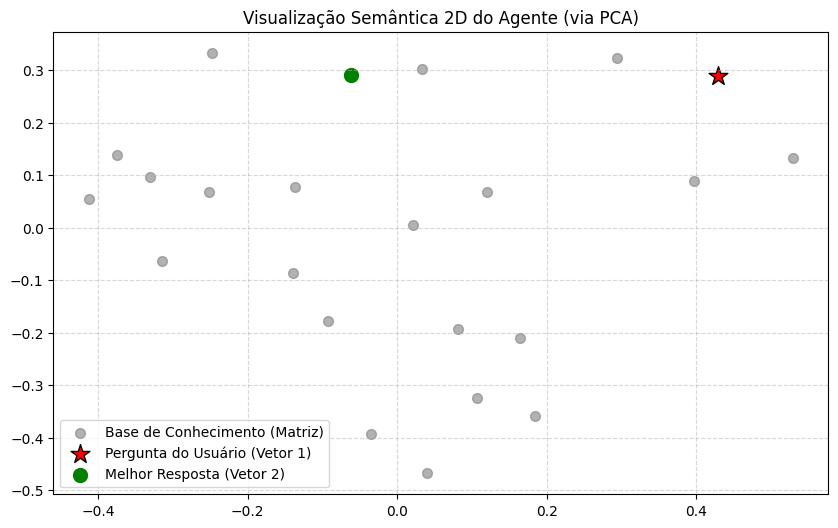

In [9]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from pypdf import PdfReader
from fastembed import TextEmbedding
from sklearn.decomposition import PCA

# primeiro fazemos o upload e a exatração dos dados do pdf
print("Faça o upload do PDF de base de conhecimento do agente:")
uploaded = files.upload()
pdf_filename = list(uploaded.keys())[0]

def extrair_frases_completas(caminho_pdf):
    leitor = PdfReader(caminho_pdf)
    texto_completo = " ".join([pagina.extract_text() for pagina in leitor.pages if pagina.extract_text()])
    texto_limpo = re.sub(r'\s+', ' ', texto_completo.replace('\n', ' '))
    frases = re.split(r'(?<=[.!?]) +', texto_limpo)
    return [f.strip() for f in frases if len(f.strip()) > 40]

trechos = extrair_frases_completas(pdf_filename)
print(f"\nExtraídos {len(trechos)} trechos/frases consistentes do PDF.")

# depois transformamos informações em vetores e matrizes
print("\nTransformando texto em vetores de 384 dimensões...")
model = TextEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# matriz de documentos: cada linha é um vetor de 384 dimensões representando um trecho do PDF
matriz_documentos = list(model.embed(trechos))

# Agora fazemos a interação do agente
pergunta = input("\nDigite a pergunta que o usuário faria ao agente: ")
# vetor da pergunta, transformando a query no mesmo espaço vetorial
vetor_pergunta = list(model.embed([pergunta]))[0]

# Aqui fazemos as operações de Álgebra Linear, que seria o buscador, fazendo a comparação de similaridade entye a pergunta e a resposta
similaridades = [np.dot(vetor_pergunta, doc_emb) for doc_emb in matriz_documentos]
indice_melhor_resposta = np.argmax(similaridades)
vetor_melhor_resposta = matriz_documentos[indice_melhor_resposta]

print(f"\n MELHOR RESPOSTA ENCONTRADA")
print(f'"{trechos[indice_melhor_resposta]}"')

# Por fim mostramos os resultados das demonstrações matemáticas respectivas (Vetor 1 vs Vetor 2)
v1 = vetor_pergunta
v2 = vetor_melhor_resposta

norma_v1 = np.linalg.norm(v1)
norma_v2 = np.linalg.norm(v2)
produto_escalar = np.dot(v1, v2)
distancia = np.linalg.norm(v1 - v2)
angulo_graus = np.degrees(np.arccos(np.clip(produto_escalar, -1.0, 1.0)))

print("\n RESULTADOS DAS OPERAÇÕES MATEMÁTICAS")
print(f"Dimensão dos vetores: {len(v1)} dimensões")
print(f"1. Norma da Pergunta (||V1||): {norma_v1:.4f}")
print(f"2. Norma da Resposta (||V2||): {norma_v2:.4f}")
print(f"3. Produto Escalar (V1 . V2): {produto_escalar:.4f}")
print(f"4. Distância Euclidiana ||V1 - V2||: {distancia:.4f}")
print(f"5. Ângulo entre V1 e V2: {angulo_graus:.2f}°")

# Aqui está contida a representação do gráfico mostrando como são realizadas as operações dentro do plano cartesiano
todos_embeddings = matriz_documentos + [vetor_pergunta]
pca = PCA(n_components=2)
coordenadas_2d = pca.fit_transform(todos_embeddings)

x_docs, y_docs = coordenadas_2d[:-1, 0], coordenadas_2d[:-1, 1]
x_pergunta, y_pergunta = coordenadas_2d[-1, 0], coordenadas_2d[-1, 1]

plt.figure(figsize=(10, 6))
plt.scatter(x_docs, y_docs, c='gray', alpha=0.6, label='Base de Conhecimento (Matriz)', s=50)
plt.scatter(x_pergunta, y_pergunta, c='red', marker='*', s=200, label='Pergunta do Usuário (Vetor 1)', edgecolors='black')
plt.scatter(x_docs[indice_melhor_resposta], y_docs[indice_melhor_resposta], c='green', s=100, label='Melhor Resposta (Vetor 2)')

plt.title("Visualização Semântica 2D do Agente (via PCA)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **SIGNIFICADO DOS RESULTADOS PARA O AGENTE RAG**

* **Produto Escalar:** O agente utiliza o produto escalar entre o vetor da pergunta ($V_1$) e os vetores da matriz de documentos ($V_2$, $V_3$, etc.) para medir o alinhamento de significado. Quanto maior o valor (mais próximo de 1), mais a resposta se alinha contextualmente à dúvida do estudante.
* **Ângulo:** O ângulo geométrico entre os vetores dita a similaridade temática. Se o ângulo for próximo de $0^\circ$, o agente tem certeza de que encontrou o texto exato que responde à pergunta do aluno. Se o ângulo for próximo a $90^\circ$, os assuntos são completamente ortogonais (diferentes).
* **Distância Euclidiana:** Mede a separação espacial entre os conceitos. O agente seleciona o trecho cuja distância euclidiana até a pergunta original seja a menor possível, garantindo que a resposta recuperada da base (como o horário de um evento ou regras de uma bolsa) pertença ao mesmo "bairro semântico" da dúvida inicial.
* **Norma:** O algoritmo força a norma dos vetores para $1$ para que o comprimento das frases não interfira na comparação. Assim, o agente consegue comparar uma pergunta curta ("quais são as condições iniciais para ingresso no Programa de Bolsas Restituíveis?") com um parágrafo longo e descritivo do edital sem distorcer o cálculo matemático.

# **FUTURO DO PROJETO**

Com base nisso que foi demonstrado, pretendemos implementar dentro do aplicativo que está sendo desenvolvido, uma espécie de chat, na qual o aluno ou o funcionário pode fazer perguntas de forma simplificada e ter uma resposta mais coerente, ao invés de precisar consultar diversos documentos que atualmente estão dispersos e são muito grandes.

Na demonstração acima, fizemos com que a resposta fosse retirada diretamente do documento, sem qualquer tipo de intervenção, porém dentro do aplicativo, haverá um agente treinado com os dados extraidos dos documentos que vai responder com mais acertividade e irá trazer uma resposta mais completa e empática para o usuário.

Por fim, abaixo temos uma imagem de uma resposta do MVP do agente. A pergunta realizada foi: "Sisa, acabei de ser demitido, acho que não vou conseguir pagar a mensalidade, o que eu faço?"
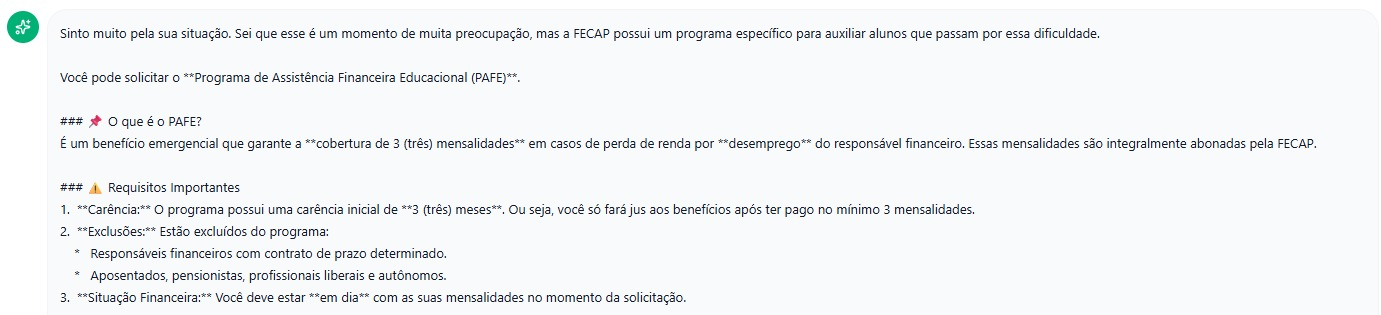